In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from scripts import model_evaluation as model_eval

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImPipeline

In [1412]:
X_train = pd.read_parquet('X_train_cleaned.parquet')
X_test = pd.read_parquet('X_test_cleaned.parquet')

y_train = pd.read_parquet('y_train.parquet').to_numpy()
y_test = pd.read_parquet('y_test.parquet').to_numpy()

In [1413]:
X_train.info()
    

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

In [1414]:
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.cols)

In [1415]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.tenure_max_ = None

    def fit(self, X, y=None):
        self.tenure_max_ = X['tenure'].max()
        self.monthly_charge_mean_ = X['MonthlyCharges'].mean()
        return self

    def transform(self, X):
        X = X.copy()

        engagementscore = (
            (X['Contract'] != 'Month-to-month').astype(int) +
            (X['StreamingTV'] == 'Yes').astype(int) +
            (X['StreamingMovies'] == 'Yes').astype(int) +
            (X['OnlineBackup'] == 'Yes').astype(int) +
            (X['DeviceProtection'] == 'Yes').astype(int) +
            (X['TechSupport'] == 'Yes').astype(int) +
            (X['OnlineSecurity'] == 'Yes').astype(int)
        )

        X['MaturityScore'] = X['tenure'] * engagementscore
        
        X['is_new_customer'] = (X['tenure'] <= 5).astype(int)

        avg_monthly_spend = X['TotalCharges'] / (X['tenure'] + 1)
        X['cost_volatility'] = X['MonthlyCharges'] - avg_monthly_spend

        return X

In [1416]:
cat_yes_no_cols = ['DeviceProtection', 'Dependents', 'PhoneService', 'OnlineBackup', 'TechSupport', 
                   'OnlineSecurity', 'PaperlessBilling']
cat_contract_cols = ['Contract']
cat_paymentmethod_cols = ['PaymentMethod']

cat_yes_no_val_order = [['Yes', 'No']]*len(cat_yes_no_cols)
cat_contract_val_order = [['Month-to-month', 'One year', 'Two year']]*len(cat_contract_cols)
cat_paymentmethod_val_order = [['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
 'Credit card (automatic)']]*len(cat_paymentmethod_cols)

num_scale_cols = ['tenure', 'MonthlyCharges', 'cost_volatility', 'MaturityScore']

drop_cols = ['gender', 'Partner', 'SeniorCitizen', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies', 'InternetService']
    

In [1417]:
yesno_encoder_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('onehot_yesno_encode', OneHotEncoder(categories=cat_yes_no_val_order, drop='first', sparse_output=False, handle_unknown='ignore')),
])

paymentmethod_encoder_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('onehot_paymentmethod_encode', OneHotEncoder(categories=cat_paymentmethod_val_order, drop='first', sparse_output=False, handle_unknown='ignore')),
])

contract_encoder_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('ordinal_contract_encode', OrdinalEncoder(categories=cat_contract_val_order))
])

scalling_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1, add_indicator=True)),
    ('scalling', StandardScaler())
])

In [1418]:
preprocessor = ColumnTransformer([
    ('ohe_yesno_encoder', yesno_encoder_pipeline, cat_yes_no_cols),
    ('ohe_paymentmethod_encoder', paymentmethod_encoder_pipeline, cat_paymentmethod_cols),
    ('ordinal_contract_encoder', contract_encoder_pipeline, cat_contract_cols),
    ('scalling', scalling_pipeline, num_scale_cols),
], remainder='passthrough')

In [1419]:
smote = SMOTE(
    sampling_strategy=0.5, 
    random_state=42
)

In [1420]:
model_pipeline = ImPipeline([
    ('feature_engineering', FeatureEngineering()),
    ('drop_cols', DropColumns(cols=drop_cols)),
    ('preprocessing', preprocessor),
    ('smote', smote),
    ('model', LogisticRegression())
])

In [1421]:
def get_params():
    return {
        "model__C":       [.005, 0.1, .01, 1, 5, 10],
        "model__penalty": ["l2"],
        "model__solver":  ["liblinear", "lbfgs"],
        "model__max_iter":  [100, 300],
    }

In [1422]:
param_grid = get_params()
 
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2,
    refit=True
)

In [1423]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.005, 0.1, ...], 'model__max_iter': [100, 300], 'model__penalty': ['l2'], 'model__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [1424]:
best_model = grid_search.best_estimator_
feature_names = best_model.named_steps['preprocessing'].get_feature_names_out()
feature_names

array(['ohe_yesno_encoder__DeviceProtection_No',
       'ohe_yesno_encoder__Dependents_No',
       'ohe_yesno_encoder__PhoneService_No',
       'ohe_yesno_encoder__OnlineBackup_No',
       'ohe_yesno_encoder__TechSupport_No',
       'ohe_yesno_encoder__OnlineSecurity_No',
       'ohe_yesno_encoder__PaperlessBilling_No',
       'ohe_paymentmethod_encoder__PaymentMethod_Mailed check',
       'ohe_paymentmethod_encoder__PaymentMethod_Bank transfer (automatic)',
       'ohe_paymentmethod_encoder__PaymentMethod_Credit card (automatic)',
       'ordinal_contract_encoder__Contract', 'scalling__tenure',
       'scalling__MonthlyCharges', 'scalling__cost_volatility',
       'scalling__MaturityScore', 'remainder__is_new_customer'],
      dtype=object)

In [1425]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'model__C': 0.1, 'model__max_iter': 100, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
0.7475569554702235


In [1426]:
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

In [1427]:
coefs = best_model.named_steps['model'].coef_[0]

In [1428]:
coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
    })
    .assign(abs_coefficient=lambda df: df["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)

In [1429]:
coef_df

,feature,coefficient,abs_coefficient
0,ordinal_contract_encoder__Contract,-0.917471,0.917471
1,scalling__MonthlyCharges,0.910768,0.910768
2,ohe_yesno_encoder__PhoneService_No,0.873699,0.873699
3,ohe_yesno_encoder__OnlineSecurity_No,0.586641,0.586641
4,scalling__tenure,-0.553523,0.553523
5,ohe_yesno_encoder__TechSupport_No,0.538784,0.538784
6,ohe_yesno_encoder__OnlineBackup_No,0.429431,0.429431
7,ohe_paymentmethod_encoder__PaymentMethod_Credi...,-0.424753,0.424753
8,remainder__is_new_customer,0.388515,0.388515
9,ohe_paymentmethod_encoder__PaymentMethod_Bank ...,-0.386873,0.386873


EVALUATION REPORT
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1035
           1       0.61      0.63      0.62       374

    accuracy                           0.79      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.79      0.80      1409

Macro F1 Score:    0.7394


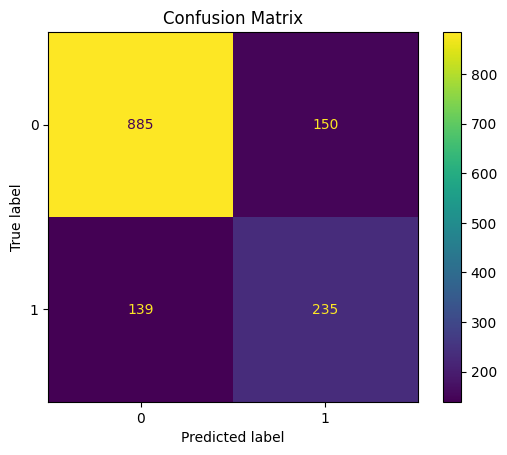

PR AUC Score: 0.661


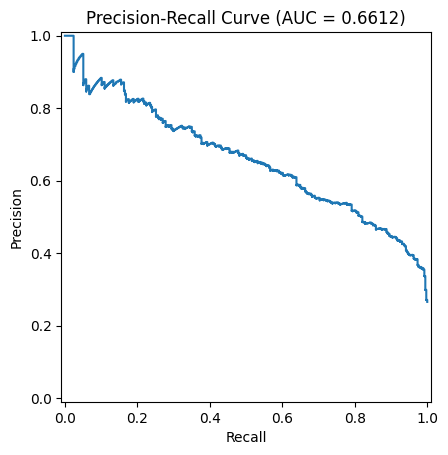

In [1430]:
model_eval.evaluate_model(y_test, y_pred, y_proba)